In [40]:
# 1. import libraries-

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix



In [41]:
# 2. Load dataset

data = pd.read_csv("dataset.csv")
print(data)

      loan_id   no_of_dependents      education  self_employed   income_annum  \
0           1                  2       Graduate             No        9600000   
1           2                  0   Not Graduate            Yes        4100000   
2           3                  3       Graduate             No        9100000   
3           4                  3       Graduate             No        8200000   
4           5                  5   Not Graduate            Yes        9800000   
...       ...                ...            ...            ...            ...   
4264     4265                  5       Graduate            Yes        1000000   
4265     4266                  0   Not Graduate            Yes        3300000   
4266     4267                  2   Not Graduate             No        6500000   
4267     4268                  1   Not Graduate             No        4100000   
4268     4269                  1       Graduate             No        9200000   

       loan_amount   loan_t

In [42]:
# checking basic info.
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB
None


In [43]:
print(data.describe())


           loan_id   no_of_dependents   income_annum   loan_amount  \
count  4269.000000        4269.000000   4.269000e+03  4.269000e+03   
mean   2135.000000           2.498712   5.059124e+06  1.513345e+07   
std    1232.498479           1.695910   2.806840e+06  9.043363e+06   
min       1.000000           0.000000   2.000000e+05  3.000000e+05   
25%    1068.000000           1.000000   2.700000e+06  7.700000e+06   
50%    2135.000000           3.000000   5.100000e+06  1.450000e+07   
75%    3202.000000           4.000000   7.500000e+06  2.150000e+07   
max    4269.000000           5.000000   9.900000e+06  3.950000e+07   

         loan_term   cibil_score   residential_assets_value  \
count  4269.000000   4269.000000               4.269000e+03   
mean     10.900445    599.936051               7.472617e+06   
std       5.709187    172.430401               6.503637e+06   
min       2.000000    300.000000              -1.000000e+05   
25%       6.000000    453.000000               2.20000

In [44]:
# 4. checking for missing values

print(data.isnull().sum())

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64


In [45]:
# 5. remove if loan_id exist

for col in data.columns:
  if 'loan_id' in data.columns:
      data.drop('loan_id', axis=1, inplace=True)


In [46]:
# 6. Encoding
le = LabelEncoder()

for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col])



In [47]:
# 7. Feature and Target split
X = data.drop(' loan_status', axis=1)
y = data[' loan_status']

In [48]:
# 8. Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
# 9. Model Training

model = DecisionTreeClassifier(
    max_depth=4, criterion='gini'
)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4)

In [50]:
# 10. Prediction
y_pred = model.predict(X_test)


In [31]:
# 11. Accuracy

acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)



Accuracy: 0.9660421545667447


In [51]:
# 12. Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))



Confusion Matrix:
 [[533   3]
 [ 25 293]]


In [52]:
# 13. Feature Importance
print("\nFeature Importance:-")
for i, col in enumerate(X.columns):
  print(col, ":",model.feature_importances_[i])


Feature Importance:-
 no_of_dependents : 0.0
 education : 0.0
 self_employed : 0.0
 income_annum : 0.011002771653092406
 loan_amount : 0.013014841599664385
 loan_term : 0.08487815778891436
 cibil_score : 0.8888353033541792
 residential_assets_value : 0.0012100515097543936
 commercial_assets_value : 0.0
 luxury_assets_value : 0.001058874094395309
 bank_asset_value : 0.0


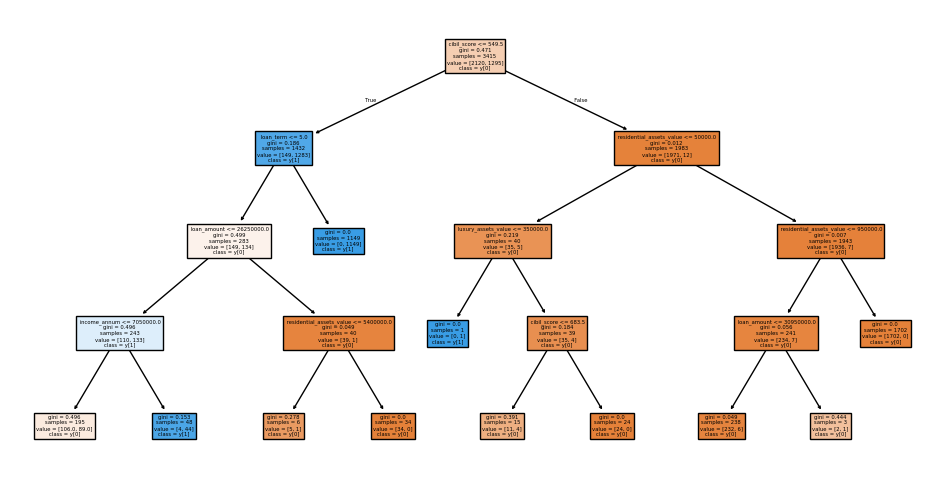

In [53]:
# 14. Decision Tree Visualization

plt.figure(figsize=(12, 6))
plot_tree(model, feature_names=X.columns, class_names= True, filled=True)
plt.show()